In [22]:
# Load Text

from general import load_text, load_json

report_path = '../../outputs/reports/2025/5.json'

reference = load_text('../../data/golden_standard/2025/5.txt')
reports = load_json(report_path)

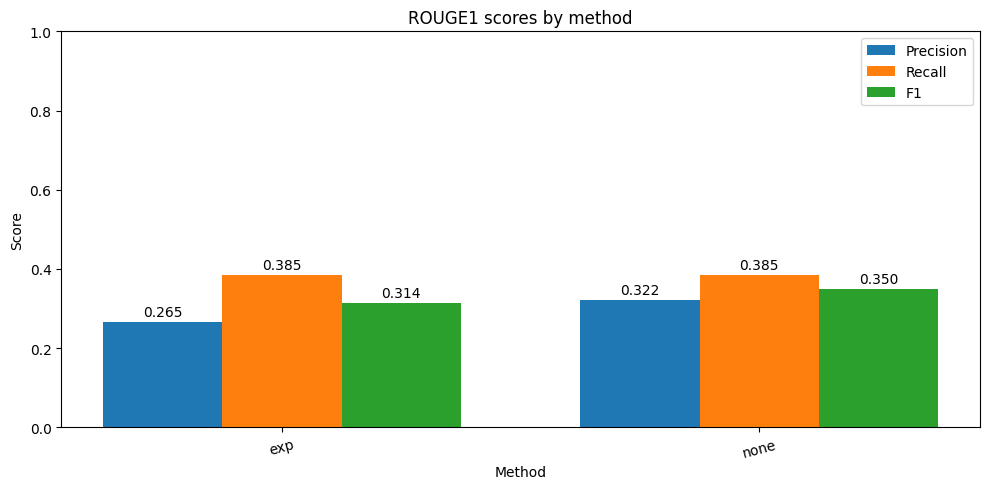

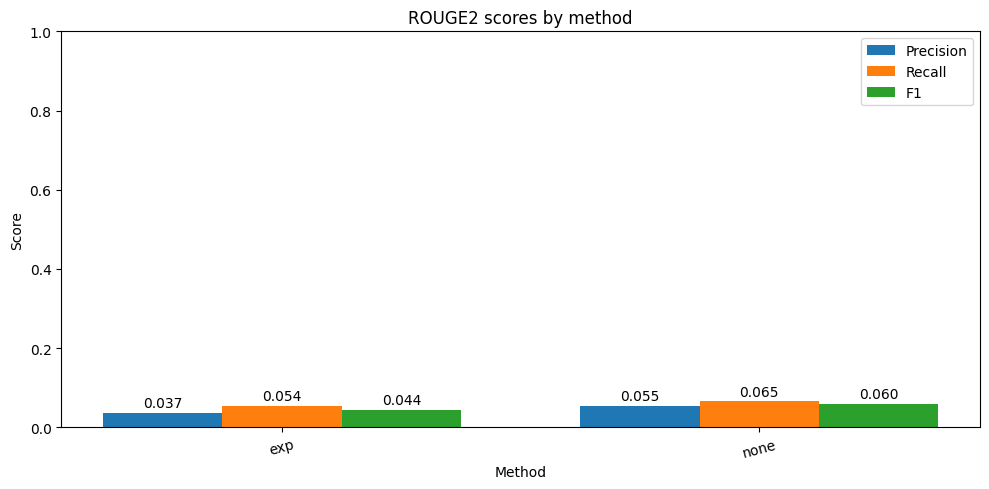

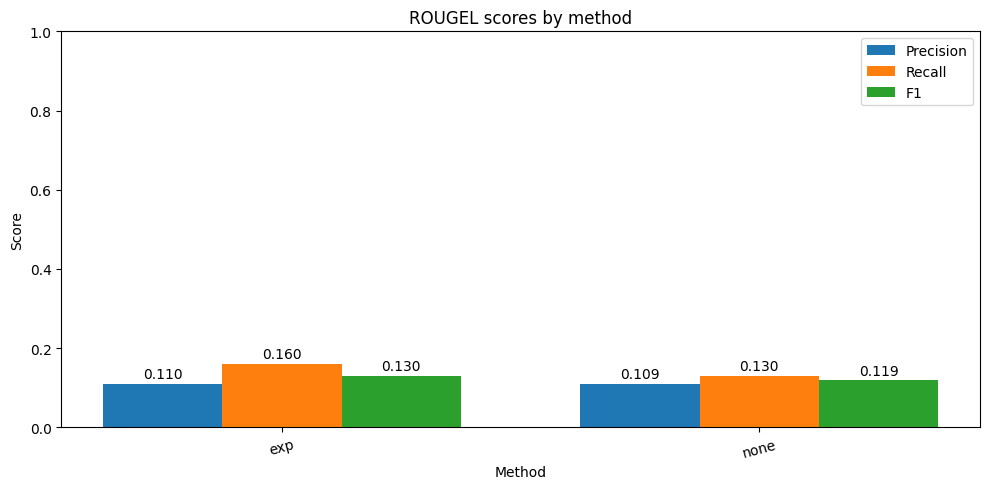

In [23]:
from rouge_score import rouge_scorer
from matplotlib import pyplot as plt
import pandas as pd

def plot_metric(df, metric_name):
    x = range(len(df))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 5))
    bars_p = ax.bar([i - width for i in x], df[f"{metric_name}_precision"], width, label="Precision")
    bars_r = ax.bar(x,                         df[f"{metric_name}_recall"],    width, label="Recall")
    bars_f = ax.bar([i + width for i in x],    df[f"{metric_name}_f1"],        width, label="F1")

    ax.set_title(f"{metric_name.upper()} scores by method")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["method"], rotation=15)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Method")
    ax.set_ylabel("Score")
    ax.legend()

    for bars in [bars_p, bars_r, bars_f]:
        ax.bar_label(bars, fmt="%.3f", padding=2)

    plt.tight_layout()
    plt.show()

def getRougeScore(reference, candidate, metrics=("rouge1", "rouge2", "rougeL")):
    scorer = rouge_scorer.RougeScorer(list(metrics), use_stemmer=True)
    scores = scorer.score(reference, candidate)

    out = {}
    for m in metrics:
        out[f"{m}_precision"] = scores[m].precision
        out[f"{m}_recall"]    = scores[m].recall
        out[f"{m}_f1"]        = scores[m].fmeasure
    return out

rows = []
for report in reports.values():
    method = report["decay_method"]
    candidate = report["summary_text"]
    scores = getRougeScore(reference, candidate)

    rows.append({"method": method, **scores})

df = pd.DataFrame(rows).sort_values("rougeL_f1", ascending=False).reset_index(drop=True)

for metric in ["rouge1", "rouge2", "rougeL"]:
    plot_metric(df, metric)